In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY2hhbmNlL3F1YXJ0by1sYWIvdGhlb3J5L0hhbV9sZWFybmluZw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap.py": 1781600678.0429904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap_external.py": 1781600678.0469904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/zipimport.py": 1781600678.926988, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/codecs.py": 1781600677.3309925, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/aliases.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/__init__.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/utf_8.py": 1781600677.414992, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/abc.py": 1781600677.29899

In [2]:
#| code-fold: true
#| code-summary: "Simulation code"
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

# ── Physical parameters ──
N = 5
d = 10.0        # μm
C6 = 862690.0   # 2π MHz μm⁶
OMEGA = 1.5     # 2π MHz
DELTA = -4.0    # 2π MHz

I2 = np.eye(2, dtype=complex)
Xm = np.array([[0, 1], [1, 0]], dtype=complex)
Zm = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = {"I": I2, "X": Xm, "Y": np.array([[0, -1j], [1j, 0]], dtype=complex), "Z": Zm}
DIM = 2**N

def kron_list(mats):
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def pauli_label(indices):
    return "".join("IXYZ"[i] for i in indices)

def pauli_matrix(label):
    return kron_list([PAULIS[c] for c in label])

def build_hamiltonian():
    H = np.zeros((DIM, DIM), dtype=complex)
    for l in range(N):
        ops = [I2]*N; ops[l] = Xm
        H += (OMEGA/2) * kron_list(ops)
    for l in range(N):
        ops_I = [I2]*N; ops_Z = [I2]*N; ops_Z[l] = Zm
        H += -DELTA * 0.5 * (kron_list(ops_I) - kron_list(ops_Z))
    for j in range(N):
        for l in range(j+1, N):
            Vjl = C6 / (abs(l-j)*d)**6
            ops_II = [I2]*N
            ops_Zl = [I2]*N; ops_Zl[l] = Zm
            ops_Zj = [I2]*N; ops_Zj[j] = Zm
            ops_ZZ = [I2]*N; ops_ZZ[j] = Zm; ops_ZZ[l] = Zm
            H += Vjl/4*(kron_list(ops_II) - kron_list(ops_Zl)
                        - kron_list(ops_Zj) + kron_list(ops_ZZ))
    return H

def pauli_decompose(H):
    coeffs = {}
    for indices in product(range(4), repeat=N):
        label = pauli_label(indices)
        mu = np.real(np.trace(H @ pauli_matrix(label))) / DIM
        if abs(mu) > 1e-14:
            coeffs[label] = mu
    return coeffs

# ── Bell sampling (structure learning) ──
def bell_sampling(H_res, tau, n_shots):
    coeffs = pauli_decompose(H_res)
    labels, probs = [], []
    for label, mu in coeffs.items():
        if label == "I"*N: continue
        probs.append(np.sin(mu*tau)**2)
        labels.append(label)
    probs = np.array(probs)
    if probs.sum() < 1e-30: return {}
    probs /= probs.sum()
    counts = np.random.multinomial(n_shots, probs)
    return {l: c for l, c in zip(labels, counts) if c > 0}

# ── Coefficient estimation ──
def estimate_coeff(H_res, label, n_shots, eps):
    coeffs = pauli_decompose(H_res)
    mu_true = coeffs.get(label, 0.0)
    noise_std = eps / np.sqrt(n_shots / 100)
    return mu_true + np.random.normal(0, noise_std)

# ── Hierarchical learning ──
LEVELS = [
    {"T": 0.08, "eps": 5e-3},
    {"T": 0.2,  "eps": 5e-3},
    {"T": 6.0,  "eps": 1e-3},
    {"T": 60.0, "eps": 1e-4},
    {"T": 1200.0, "eps": 1e-5},
]

np.random.seed(42)
H = build_hamiltonian()
true_coeffs = pauli_decompose(H)

id_label = "I"*N
H_hat = true_coeffs[id_label] * np.eye(DIM, dtype=complex)
hat_coeffs = {id_label: true_coeffs[id_label]}
table_rows = []

for j, lev in enumerate(LEVELS):
    T, eps = lev["T"], lev["eps"]
    H_res = H - H_hat
    r1 = max(1, int(np.ceil(T * sum(abs(v) for v in true_coeffs.values()) / 0.1)))
    tau = T / r1
    discovered = bell_sampling(H_res, tau, 2000)
    for label in discovered:
        hat_coeffs[label] = hat_coeffs.get(label, 0.0) + estimate_coeff(H_res, label, 1000, eps)
    H_hat = sum(mu * pauli_matrix(l) for l, mu in hat_coeffs.items())
    res_norm = np.linalg.norm(H - H_hat, ord=2)
    table_rows.append((j+1, T, eps, len(hat_coeffs), res_norm))

In [3]:
#| label: tbl-convergence
#| tbl-cap: Hierarchical learning convergence
from IPython.display import Markdown
lines = ["| Level | $T$ ($\\mu$s) | $\\varepsilon$ | # Pauli terms | $\\|H-\\hat{H}\\|$ (2$\\pi$ MHz) |",
         "|:-----:|:-----------:|:----------:|:-------------:|:---------------------------:|"]
for level, T, eps, n_terms, res in table_rows:
    lines.append(f"| {level} | {T:.2f} | {eps:.0e} | {n_terms} | {res:.6f} |")
Markdown("\n".join(lines))

| Level | $T$ ($\mu$s) | $\varepsilon$ | # Pauli terms | $\|H-\hat{H}\|$ (2$\pi$ MHz) |
|:-----:|:-----------:|:----------:|:-------------:|:---------------------------:|
| 1 | 0.08 | 5e-03 | 14 | 0.233111 |
| 2 | 0.20 | 5e-03 | 15 | 0.017544 |
| 3 | 6.00 | 1e-03 | 20 | 0.002148 |
| 4 | 60.00 | 1e-04 | 21 | 0.000274 |
| 5 | 1200.00 | 1e-05 | 21 | 0.000026 |

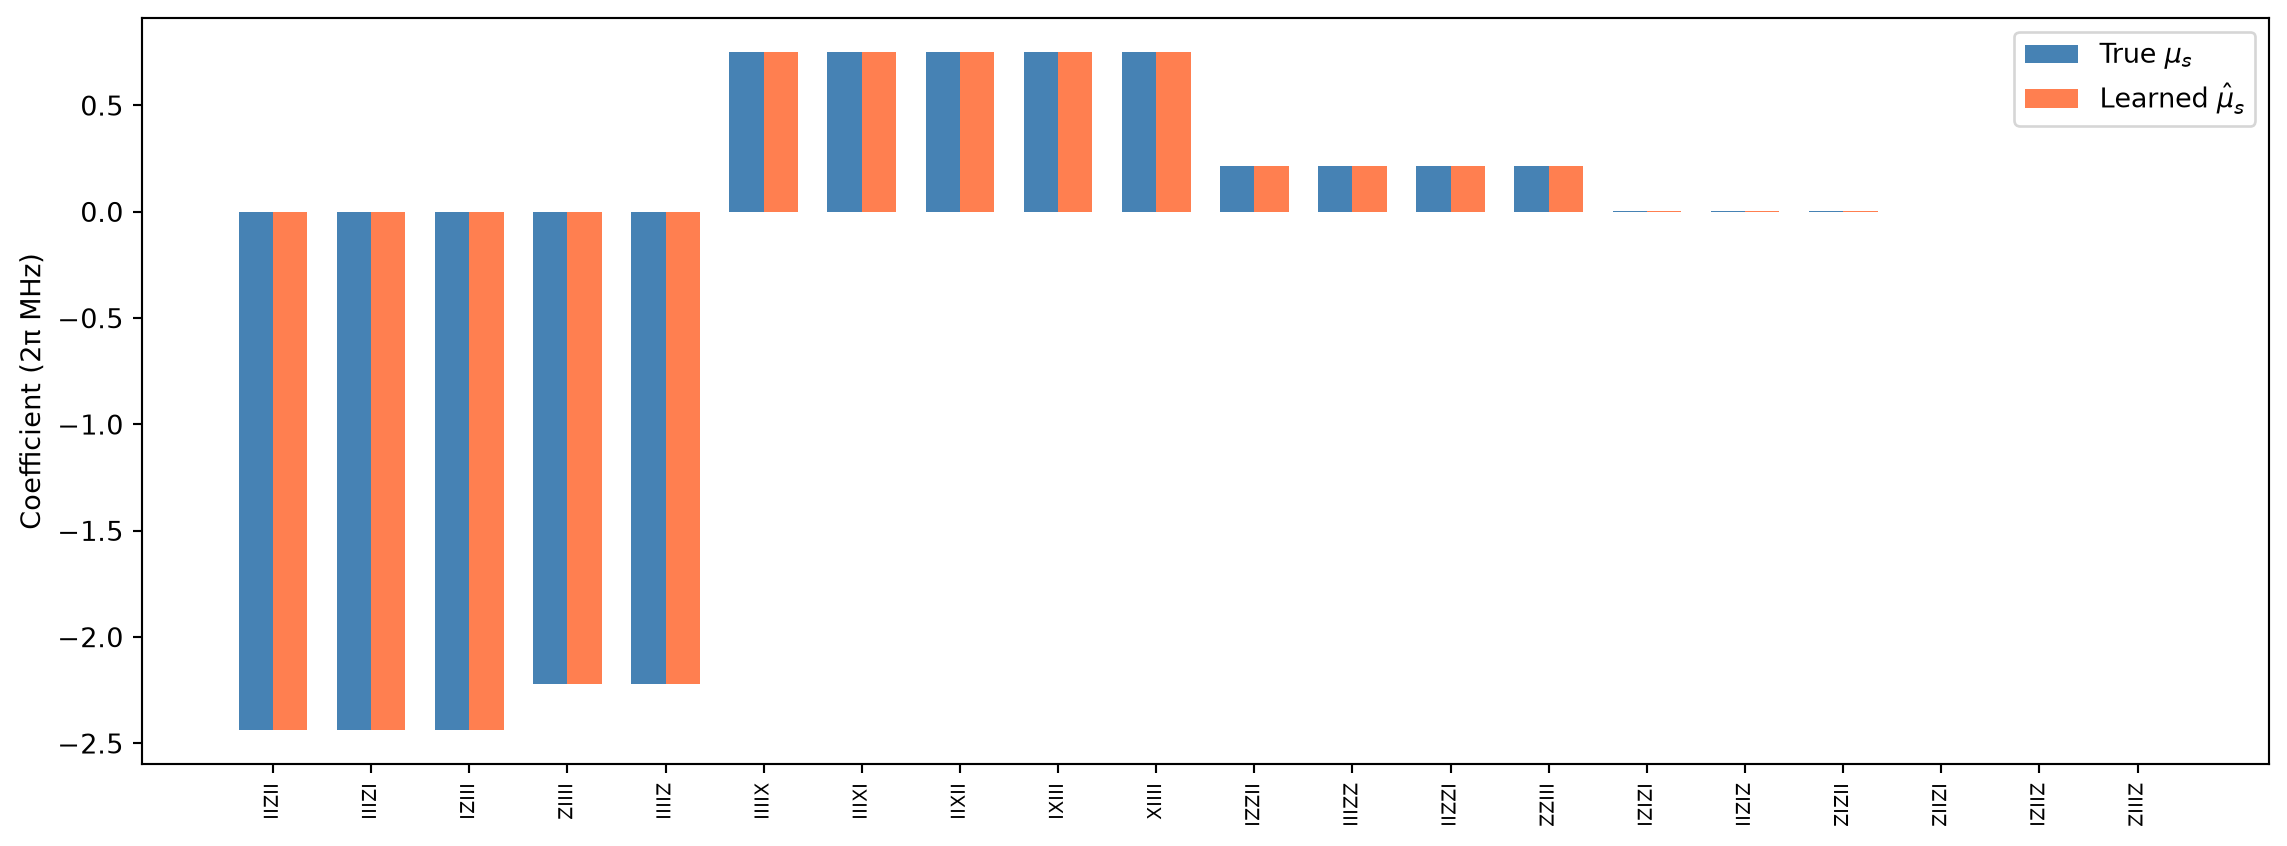

In [4]:
#| label: fig-coefficients
#| fig-cap: Comparison of learned and true Pauli coefficients for the 5-atom Rydberg chain.
all_labels = sorted(
    set(list(true_coeffs.keys()) + list(hat_coeffs.keys())),
    key=lambda s: -abs(true_coeffs.get(s, 0.0))
)
all_labels = [l for l in all_labels if l != "I"*N][:25]
true_vals = [true_coeffs.get(l, 0.0) for l in all_labels]
hat_vals = [hat_coeffs.get(l, 0.0) for l in all_labels]

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(all_labels))
w = 0.35
ax.bar(x - w/2, true_vals, w, label=r"True $\mu_s$", color="steelblue")
ax.bar(x + w/2, hat_vals, w, label=r"Learned $\hat{\mu}_s$", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax.set_ylabel("Coefficient (2π MHz)")
ax.legend()
fig.tight_layout()
plt.show()

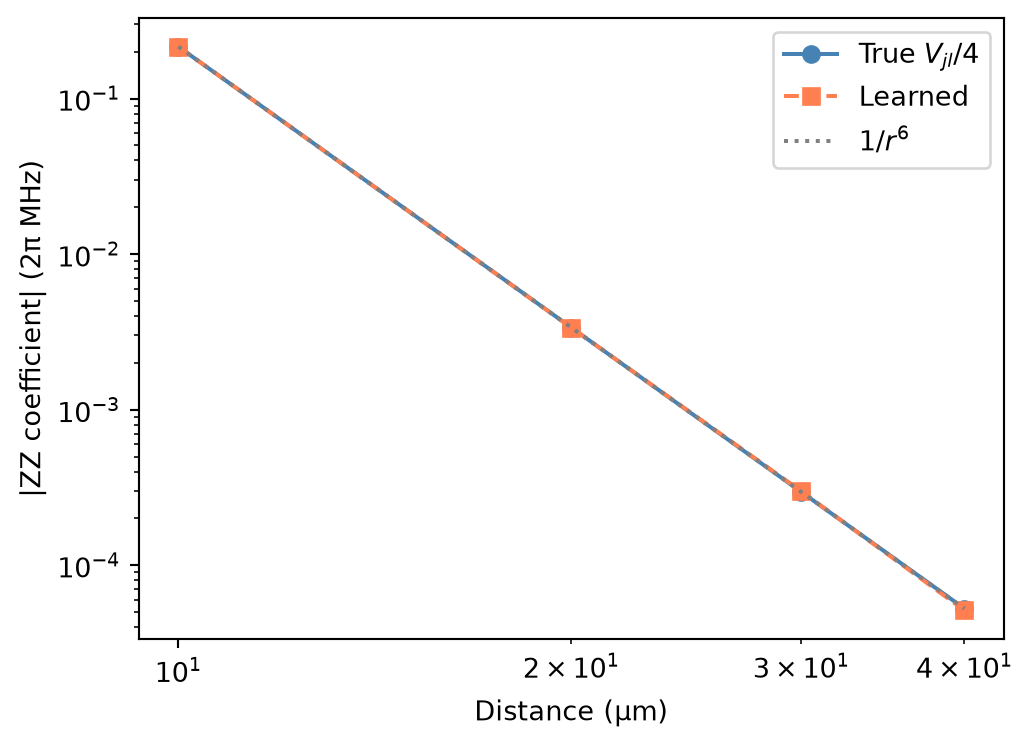

In [5]:
#| label: fig-vdw
#| fig-cap: Recovery of the $1/r^6$ van der Waals decay from learned ZZ coefficients.
zz_true, zz_learned = {}, {}
for j in range(N):
    for l in range(j+1, N):
        label = list("I"*N); label[j] = "Z"; label[l] = "Z"
        label = "".join(label)
        dist = abs(l-j)*d
        zz_true[dist] = true_coeffs.get(label, 0.0)
        zz_learned[dist] = hat_coeffs.get(label, 0.0)

dists = sorted(zz_true.keys())
fig2, ax2 = plt.subplots(figsize=(5.5, 4))
ax2.loglog(dists, [abs(zz_true[dd]) for dd in dists], "o-",
           label=r"True $V_{jl}/4$", color="steelblue")
ax2.loglog(dists, [max(abs(zz_learned.get(dd, 0)), 1e-15) for dd in dists],
           "s--", label="Learned", color="coral")
d_ref = np.array(dists)
scale = abs(zz_true[dists[0]]) * dists[0]**6
ax2.loglog(d_ref, scale / d_ref**6, ":", color="gray", label=r"$1/r^6$")
ax2.set_xlabel("Distance (μm)")
ax2.set_ylabel("|ZZ coefficient| (2π MHz)")
ax2.legend()
fig2.tight_layout()
plt.show()